In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('../data/processed/punjab_food_prices_features.csv', parse_dates=['date'])

print('Shape:', df.shape)


Shape: (95, 31)


In [4]:
# Define features and targets
FEATURES = [c for c in df.columns if c not in ['date', 'wheat_price', 'rice_price', 'sugar_price', 'year']]
TARGETS = ['wheat_price', 'rice_price', 'sugar_price']

# Time series split — never shuffle price data
tscv = TimeSeriesSplit(n_splits=5)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Store results
results = []

for target in TARGETS:
    X = df[FEATURES]
    y = df[target]
    
    for model_name, model in models.items():
        mae_scores = []
        rmse_scores = []
        
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            
            mae_scores.append(mean_absolute_error(y_test, preds))
            rmse_scores.append(np.sqrt(mean_squared_error(y_test, preds)))
        
        results.append({
            'Commodity': target.replace('_price', '').title(),
            'Model': model_name,
            'MAE (PKR/kg)': round(np.mean(mae_scores), 2),
            'RMSE (PKR/kg)': round(np.mean(rmse_scores), 2)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Commodity             Model  MAE (PKR/kg)  RMSE (PKR/kg)
    Wheat Linear Regression          4.72           5.41
    Wheat     Random Forest          2.08           2.59
    Wheat           XGBoost          2.17           2.63
     Rice Linear Regression          4.88           5.98
     Rice     Random Forest          5.18           5.92
     Rice           XGBoost          5.45           6.20
    Sugar Linear Regression          4.38           5.12
    Sugar     Random Forest          7.01           7.84
    Sugar           XGBoost          7.10           8.03


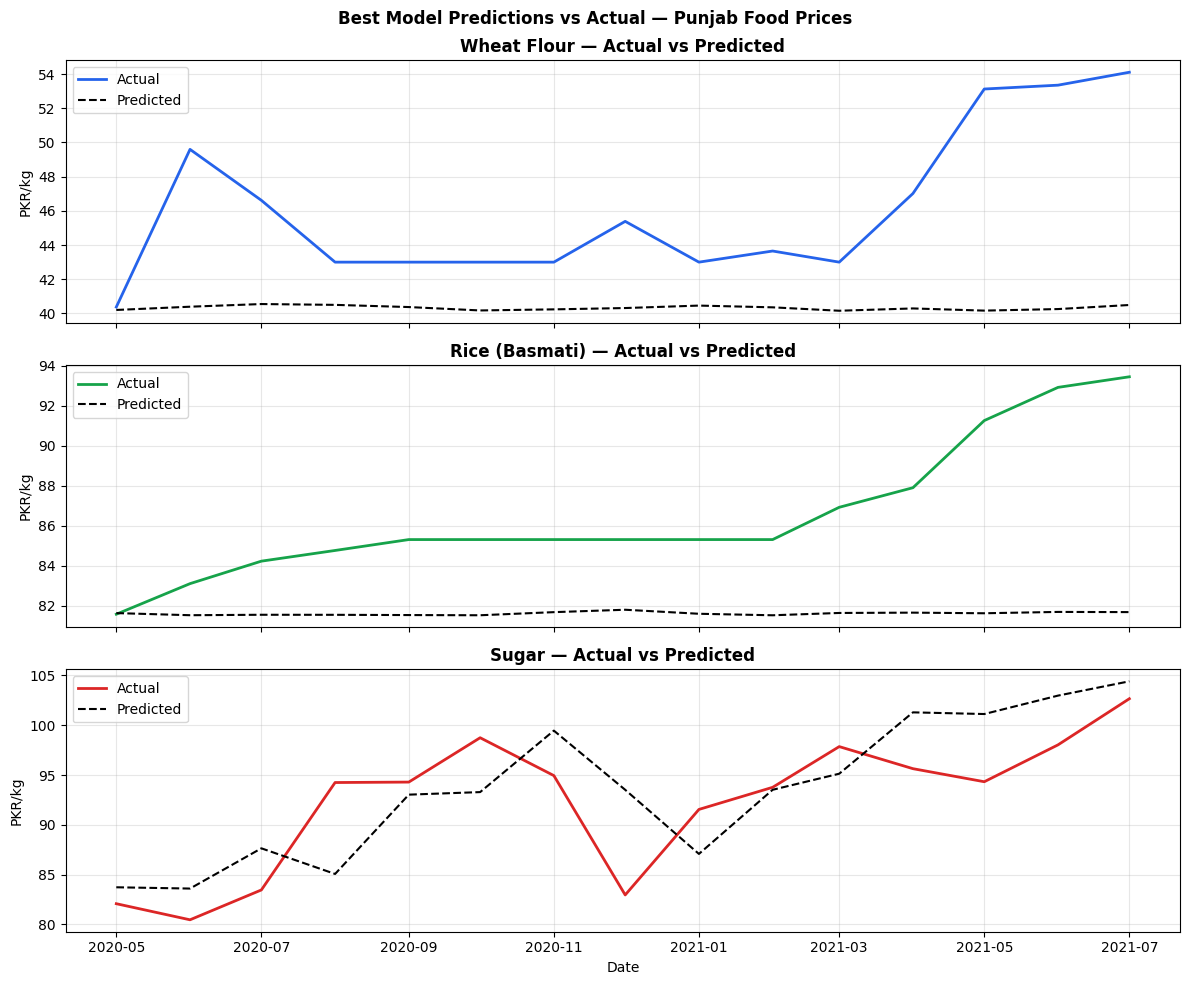

In [5]:
best_models = {
    'wheat_price': RandomForestRegressor(n_estimators=100, random_state=42),
    'rice_price': RandomForestRegressor(n_estimators=100, random_state=42),
    'sugar_price': LinearRegression()
}

X = df[FEATURES]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

colors = {'wheat_price': '#2563EB', 'rice_price': '#16A34A', 'sugar_price': '#DC2626'}
labels = {'wheat_price': 'Wheat Flour', 'rice_price': 'Rice (Basmati)', 'sugar_price': 'Sugar'}

for ax, (target, model) in zip(axes, best_models.items()):
    # Use last split for visual
    splits = list(tscv.split(X))
    train_idx, test_idx = splits[-1]
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = df[target].iloc[train_idx], df[target].iloc[test_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    test_dates = df['date'].iloc[test_idx]
    
    ax.plot(test_dates, y_test.values, label='Actual', color=colors[target], linewidth=2)
    ax.plot(test_dates, preds, label='Predicted', color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'{labels[target]} — Actual vs Predicted', fontweight='bold')
    ax.set_ylabel('PKR/kg')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Best Model Predictions vs Actual — Punjab Food Prices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Check what period the last split test set covers
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

print('Training period:', df['date'].iloc[train_idx].min(), '→', df['date'].iloc[train_idx].max())
print('Test period:', df['date'].iloc[test_idx].min(), '→', df['date'].iloc[test_idx].max())

Training period: 2013-09-01 00:00:00 → 2020-04-01 00:00:00
Test period: 2020-05-01 00:00:00 → 2021-07-01 00:00:00


In [7]:
from prophet import Prophet

prophet_results = []

for target in TARGETS:
    # Prophet needs columns named ds and y
    prophet_df = df[['date', target]].rename(columns={'date': 'ds', target: 'y'})
    
    # Train on same split as before
    train = prophet_df.iloc[train_idx]
    test = prophet_df.iloc[test_idx]
    
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(train)
    
    forecast = m.predict(test[['ds']])
    preds = forecast['yhat'].values
    actuals = test['y'].values
    
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    
    prophet_results.append({
        'Commodity': target.replace('_price', '').title(),
        'Model': 'Prophet',
        'MAE (PKR/kg)': round(mae, 2),
        'RMSE (PKR/kg)': round(rmse, 2)
    })

prophet_df_results = pd.DataFrame(prophet_results)
print(prophet_df_results.to_string(index=False))

Importing plotly failed. Interactive plots will not work.
02:50:11 - cmdstanpy - INFO - Chain [1] start processing
02:50:14 - cmdstanpy - INFO - Chain [1] done processing
02:50:14 - cmdstanpy - INFO - Chain [1] start processing
02:50:16 - cmdstanpy - INFO - Chain [1] done processing
02:50:16 - cmdstanpy - INFO - Chain [1] start processing
02:50:18 - cmdstanpy - INFO - Chain [1] done processing


Commodity   Model  MAE (PKR/kg)  RMSE (PKR/kg)
    Wheat Prophet          4.14           6.13
     Rice Prophet          4.39           5.25
    Sugar Prophet          3.23           3.87


In [8]:
# Combine all results
final_results = pd.concat([results_df, prophet_df_results], ignore_index=True)

# Pivot for clean comparison
comparison = final_results.pivot_table(
    index='Model',
    columns='Commodity',
    values='MAE (PKR/kg)'
).round(2)

print('=== FINAL MODEL COMPARISON (MAE PKR/kg) — lower is better ===\n')
print(comparison.to_string())

# Highlight best model per commodity
print('\n=== BEST MODEL PER COMMODITY ===')
for commodity in ['Wheat', 'Rice', 'Sugar']:
    subset = final_results[final_results['Commodity'] == commodity]
    best = subset.loc[subset['MAE (PKR/kg)'].idxmin()]
    print(f"{commodity}: {best['Model']} (MAE: {best['MAE (PKR/kg)']} PKR/kg)")

=== FINAL MODEL COMPARISON (MAE PKR/kg) — lower is better ===

Commodity          Rice  Sugar  Wheat
Model                                
Linear Regression  4.88   4.38   4.72
Prophet            4.39   3.23   4.14
Random Forest      5.18   7.01   2.08
XGBoost            5.45   7.10   2.17

=== BEST MODEL PER COMMODITY ===
Wheat: Random Forest (MAE: 2.08 PKR/kg)
Rice: Prophet (MAE: 4.39 PKR/kg)
Sugar: Prophet (MAE: 3.23 PKR/kg)


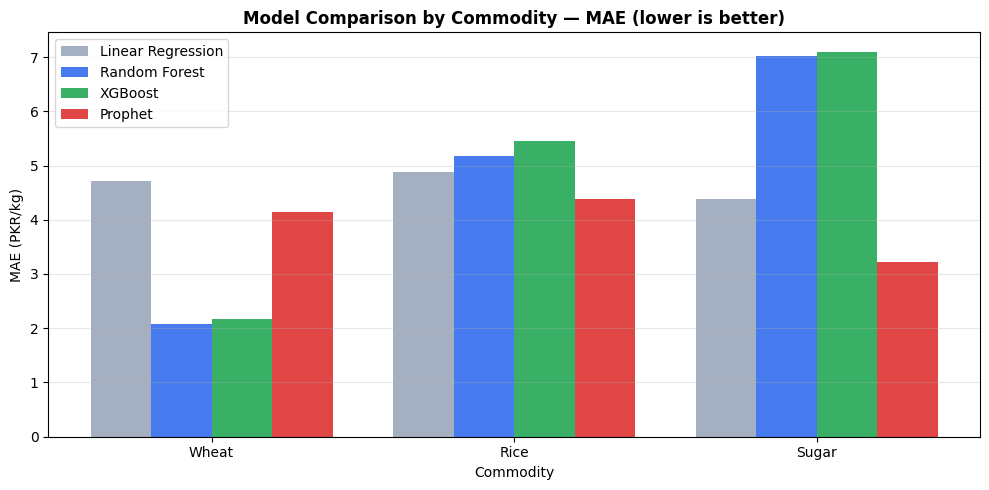

In [9]:
# Save results
final_results.to_csv('../outputs/model_comparison.csv', index=False)

# Visualise comparison
fig, ax = plt.subplots(figsize=(10, 5))

commodities = ['Wheat', 'Rice', 'Sugar']
models = ['Linear Regression', 'Random Forest', 'XGBoost', 'Prophet']
colors = ['#94A3B8', '#2563EB', '#16A34A', '#DC2626']

x = np.arange(len(commodities))
width = 0.2

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [final_results[(final_results['Model']==model) & 
            (final_results['Commodity']==c)]['MAE (PKR/kg)'].values[0] 
            for c in commodities]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)

ax.set_xlabel('Commodity')
ax.set_ylabel('MAE (PKR/kg)')
ax.set_title('Model Comparison by Commodity — MAE (lower is better)', fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(commodities)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import joblib
import os
os.makedirs('../models', exist_ok=True)

# Train best models on full data
best = {
    'wheat': RandomForestRegressor(n_estimators=100, random_state=42),
    'rice': Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False),
    'sugar': Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
}

X_full = df[FEATURES]

# Random Forest for wheat
best['wheat'].fit(X_full, df['wheat_price'])
joblib.dump(best['wheat'], '../models/wheat_random_forest.pkl')

# Prophet for rice and sugar
for target in ['rice', 'sugar']:
    prophet_df = df[['date', f'{target}_price']].rename(
        columns={'date': 'ds', f'{target}_price': 'y'}
    )
    best[target].fit(prophet_df)
    joblib.dump(best[target], f'../models/{target}_prophet.pkl')

print('All models saved.')

02:52:52 - cmdstanpy - INFO - Chain [1] start processing
02:52:54 - cmdstanpy - INFO - Chain [1] done processing
02:52:54 - cmdstanpy - INFO - Chain [1] start processing
02:52:55 - cmdstanpy - INFO - Chain [1] done processing


All models saved.
